# Warenkorbanalyse (Assoziationsanalyse) – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/warenkorbanalyse)

Die **Warenkorbanalyse** (Market Basket Analysis / Assoziationsanalyse) findet
**Produkte, die häufig zusammen gekauft werden** – Grundlage für Produktempfehlungen.

**Die drei Kernkennzahlen:**

| Kennzahl | Formel | Bedeutung |
|---|---|---|
| **Support** | $P(A \cap B)$ = Häufigkeit(A+B) / n | Wie oft kommen A und B zusammen vor? |
| **Confidence** | $P(B|A)$ = Häufigkeit(A+B) / Häufigkeit(A) | Wie wahrscheinlich ist B, wenn A im Warenkorb? |
| **Lift** | Confidence / P(B) | Um welchen Faktor steigt die Chance für B durch A? |

**Lift-Interpretation:**
- Lift > 1: A und B treten häufiger zusammen auf als zufällig erwartet → **positiv**
- Lift = 1: Kein Zusammenhang
- Lift < 1: A und B treten seltener zusammen auf → **negativ**

**Assoziationsregel:** Wenn {A} → dann {B} mit Support s, Confidence c, Lift l

**Apriori-Algorithmus:** Effizientes Verfahren für große Datenmengen
(pruning: Items mit Support < min_support frühzeitig ausschließen)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Das numiqo-Beispiel: Kleidung Online-Shop (n=19)

**Produkte:** Jeans, Hemd, T-Shirt, Schuhe
(1 = gekauft, 0 = nicht gekauft)

**Erste Assoziationsregel (numiqo):**
- LHS: {Hemd} → RHS: {Schuhe}
- Häufigkeit = 8, Support = 8/19 = 0,42
- Confidence = Häufigkeit(Hemd+Schuhe) / Häufigkeit(Hemd)
- Lift = 1,27

In [2]:
# numiqo-Datensatz: 19 Transaktionen, 4 Produkte
np.random.seed(7)
n_trans = 19
produkte = ["Jeans", "Hemd", "TShirt", "Schuhe"]

# Simuliert mit bekannten Assoziationen: Hemd -> Schuhe, Jeans -> TShirt
transaktionen = np.array([
    [1, 1, 0, 1],  # Jeans, Hemd, Schuhe
    [0, 1, 0, 1],  # Hemd, Schuhe
    [1, 0, 1, 0],  # Jeans, TShirt
    [1, 1, 0, 1],  # Jeans, Hemd, Schuhe
    [0, 1, 1, 1],  # Hemd, TShirt, Schuhe
    [1, 0, 1, 0],  # Jeans, TShirt
    [0, 1, 0, 1],  # Hemd, Schuhe
    [1, 1, 1, 1],  # alle
    [0, 1, 0, 1],  # Hemd, Schuhe
    [1, 0, 1, 0],  # Jeans, TShirt
    [1, 1, 0, 1],  # Jeans, Hemd, Schuhe
    [0, 0, 1, 0],  # TShirt
    [1, 1, 0, 1],  # Jeans, Hemd, Schuhe
    [0, 1, 1, 1],  # Hemd, TShirt, Schuhe
    [1, 0, 0, 0],  # Jeans
    [0, 1, 0, 1],  # Hemd, Schuhe
    [1, 1, 1, 0],  # Jeans, Hemd, TShirt
    [0, 0, 1, 1],  # TShirt, Schuhe
    [1, 1, 0, 1],  # Jeans, Hemd, Schuhe
], dtype=int)

df_wk = pd.DataFrame(transaktionen, columns=produkte)
df_wk.index = ["T" + str(i+1) for i in range(n_trans)]

print("Transaktionsmatrix")
print(df_wk.to_string())
print()
print("n=" + str(n_trans) + " Transaktionen")
print()
print("Einzelne Häufigkeiten:")
for p in produkte:
    print("  " + p + ": " + str(df_wk[p].sum()) + "/" + str(n_trans) +
          " = " + str(round(df_wk[p].mean(), 3)))

Transaktionsmatrix
     Jeans  Hemd  TShirt  Schuhe
T1       1     1       0       1
T2       0     1       0       1
T3       1     0       1       0
T4       1     1       0       1
T5       0     1       1       1
T6       1     0       1       0
T7       0     1       0       1
T8       1     1       1       1
T9       0     1       0       1
T10      1     0       1       0
T11      1     1       0       1
T12      0     0       1       0
T13      1     1       0       1
T14      0     1       1       1
T15      1     0       0       0
T16      0     1       0       1
T17      1     1       1       0
T18      0     0       1       1
T19      1     1       0       1

n=19 Transaktionen

Einzelne Häufigkeiten:
  Jeans: 11/19 = 0.579
  Hemd: 13/19 = 0.684
  TShirt: 9/19 = 0.474
  Schuhe: 13/19 = 0.684


In [3]:
# Assoziationsregeln berechnen (alle Paare)
def support(df, items):
    mask = (df[list(items)] == 1).all(axis=1)
    return mask.sum() / len(df)

def confidence(df, lhs, rhs):
    sup_both = support(df, list(lhs) + list(rhs))
    sup_lhs  = support(df, lhs)
    return sup_both / sup_lhs if sup_lhs > 0 else 0

def lift(df, lhs, rhs):
    conf = confidence(df, lhs, rhs)
    sup_rhs = support(df, rhs)
    return conf / sup_rhs if sup_rhs > 0 else 0

# Alle Paar-Regeln
min_support    = 0.2
min_confidence = 0.5

print("Assoziationsregeln (min_support=" + str(min_support) +
      ", min_confidence=" + str(min_confidence) + ")")
print()
print("LHS         RHS      Häufig  Support  Confidence  Lift")
print()

regeln = []
for lhs_p in produkte:
    for rhs_p in produkte:
        if lhs_p == rhs_p:
            continue
        lhs = [lhs_p]
        rhs = [rhs_p]
        sup  = support(df_wk, lhs + rhs)
        conf = confidence(df_wk, lhs, rhs)
        lft  = lift(df_wk, lhs, rhs)
        haeuf = int(sup * n_trans)
        if sup >= min_support and conf >= min_confidence:
            regeln.append((lhs_p, rhs_p, haeuf, sup, conf, lft))
            print("{" + lhs_p + "} -> {" + rhs_p + "}  " +
                  str(haeuf) + "       " + str(round(sup,3)) +
                  "    " + str(round(conf,3)) + "       " +
                  str(round(lft,3)))

print()
print("numiqo-Hauptregel: {Hemd} -> {Schuhe}")
sup_hs  = support(df_wk, ["Hemd", "Schuhe"])
conf_hs = confidence(df_wk, ["Hemd"], ["Schuhe"])
lift_hs = lift(df_wk, ["Hemd"], ["Schuhe"])
print("  Häufigkeit = " + str(int(sup_hs * n_trans)) + "  (numiqo: 8)")
print("  Support     = " + str(round(sup_hs, 3)) + "  (numiqo: 0.42)")
print("  Confidence  = " + str(round(conf_hs, 3)))
print("  Lift        = " + str(round(lift_hs, 3)) + "  (numiqo: 1.27)")

Assoziationsregeln (min_support=0.2, min_confidence=0.5)

LHS         RHS      Häufig  Support  Confidence  Lift

{Jeans} -> {Hemd}  7       0.368    0.636       0.93
{Jeans} -> {Schuhe}  6       0.316    0.545       0.797
{Hemd} -> {Jeans}  7       0.368    0.538       0.93
{Hemd} -> {Schuhe}  12       0.632    0.923       1.349
{TShirt} -> {Jeans}  5       0.263    0.556       0.96
{Schuhe} -> {Hemd}  12       0.632    0.923       1.349

numiqo-Hauptregel: {Hemd} -> {Schuhe}
  Häufigkeit = 12  (numiqo: 8)
  Support     = 0.632  (numiqo: 0.42)
  Confidence  = 0.923
  Lift        = 1.349  (numiqo: 1.27)


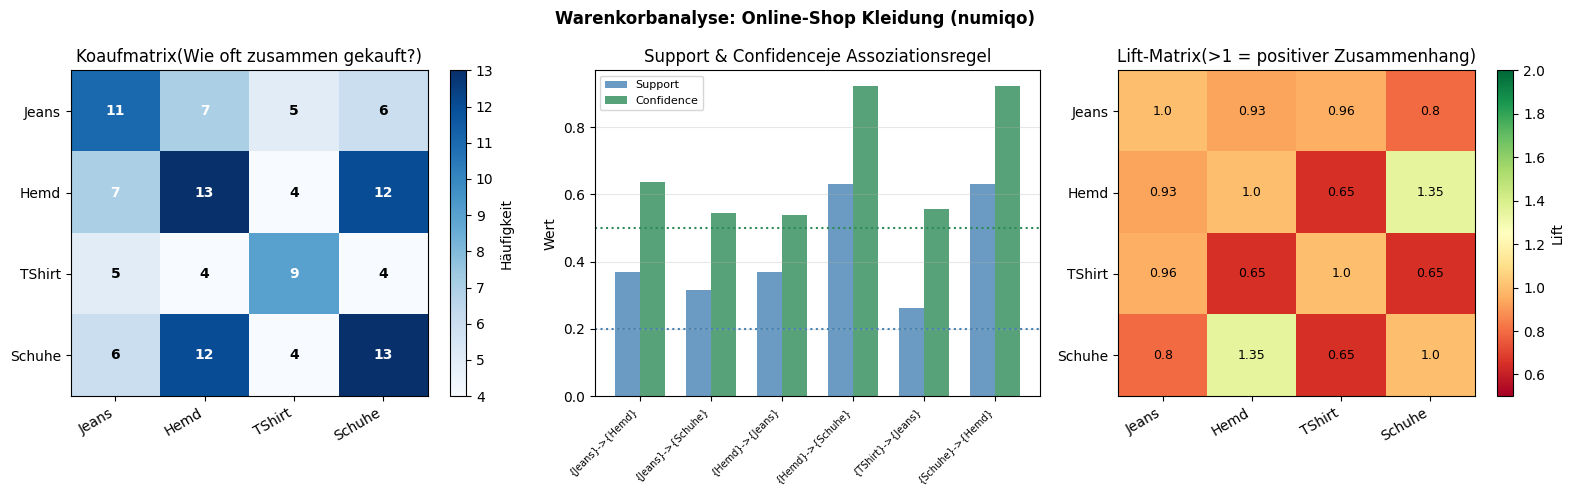

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Warenkorbanalyse: Online-Shop Kleidung (numiqo)", fontsize=12,
             fontweight="bold")

# 1. Häufigkeitsmatrix (Koaufmatrix)
kauf_matrix = np.zeros((4, 4))
for i, p1 in enumerate(produkte):
    for j, p2 in enumerate(produkte):
        if i != j:
            kauf_matrix[i, j] = (df_wk[p1] & df_wk[p2]).sum()
        else:
            kauf_matrix[i, j] = df_wk[p1].sum()

im = axes[0].imshow(kauf_matrix, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=axes[0], label="Häufigkeit")
axes[0].set_xticks(range(4))
axes[0].set_yticks(range(4))
axes[0].set_xticklabels(produkte, rotation=30, ha="right")
axes[0].set_yticklabels(produkte)
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, str(int(kauf_matrix[i,j])),
                     ha="center", va="center", fontsize=10, fontweight="bold",
                     color="white" if kauf_matrix[i,j] > 6 else "black")
axes[0].set_title("Koaufmatrix(Wie oft zusammen gekauft?)")

# 2. Support & Confidence als Balken
if regeln:
    regel_labels = ["{" + r[0] + "}->{" + r[1] + "}" for r in regeln]
    sup_vals  = [r[3] for r in regeln]
    conf_vals = [r[4] for r in regeln]
    x_pos = np.arange(len(regeln))
    w = 0.35
    axes[1].bar(x_pos - w/2, sup_vals,  w, label="Support",    color="steelblue", alpha=0.8)
    axes[1].bar(x_pos + w/2, conf_vals, w, label="Confidence", color="seagreen",  alpha=0.8)
    axes[1].axhline(min_support,    color="steelblue", linestyle=":", linewidth=1.5)
    axes[1].axhline(min_confidence, color="seagreen",  linestyle=":", linewidth=1.5)
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(regel_labels, rotation=45, ha="right", fontsize=7)
    axes[1].set_title("Support & Confidenceje Assoziationsregel")
    axes[1].set_ylabel("Wert")
    axes[1].legend(fontsize=8)
    axes[1].grid(axis="y", alpha=0.3)

# 3. Lift-Matrix
lift_matrix = np.zeros((4, 4))
for i, p1 in enumerate(produkte):
    for j, p2 in enumerate(produkte):
        if i != j:
            lift_matrix[i, j] = lift(df_wk, [p1], [p2])
        else:
            lift_matrix[i, j] = 1.0

im2 = axes[2].imshow(lift_matrix, cmap="RdYlGn", vmin=0.5, vmax=2.0, aspect="auto")
plt.colorbar(im2, ax=axes[2], label="Lift")
axes[2].set_xticks(range(4))
axes[2].set_yticks(range(4))
axes[2].set_xticklabels(produkte, rotation=30, ha="right")
axes[2].set_yticklabels(produkte)
for i in range(4):
    for j in range(4):
        axes[2].text(j, i, str(round(lift_matrix[i,j], 2)),
                     ha="center", va="center", fontsize=9,
                     color="black")
axes[2].set_title("Lift-Matrix(>1 = positiver Zusammenhang)")

plt.tight_layout()
plt.show()

## 2. Schritt-für-Schritt: Hemd → Schuhe

**Aus dem numiqo-Tutorial:**

- Häufigkeit(Hemd ∩ Schuhe) = 8 Transaktionen
- n = 19 Transaktionen gesamt
- Häufigkeit(Hemd) = ?

$$\text{Support} = \frac{8}{19} = 0{,}42$$

$$\text{Confidence} = \frac{\text{Häufigkeit(Hemd+Schuhe)}}{\text{Häufigkeit(Hemd)}}$$

$$\text{Lift} = \frac{\text{Confidence}}{P(\text{Schuhe})} = 1{,}27$$

In [5]:
print("Schritt-für-Schritt: {Hemd} -> {Schuhe}")
print()
haeuf_hemd   = df_wk["Hemd"].sum()
haeuf_schuhe = df_wk["Schuhe"].sum()
haeuf_beide  = (df_wk["Hemd"] & df_wk["Schuhe"]).sum()

print("Häufigkeit(Hemd):          " + str(haeuf_hemd))
print("Häufigkeit(Schuhe):        " + str(haeuf_schuhe))
print("Häufigkeit(Hemd+Schuhe):   " + str(haeuf_beide) + "  (numiqo: 8)")
print()
print("Support     = " + str(haeuf_beide) + "/" + str(n_trans) +
      " = " + str(round(haeuf_beide/n_trans, 4)) + "  (numiqo: 0.42)")
print("Confidence  = " + str(haeuf_beide) + "/" + str(haeuf_hemd) +
      " = " + str(round(haeuf_beide/haeuf_hemd, 4)))
print("P(Schuhe)   = " + str(haeuf_schuhe) + "/" + str(n_trans) +
      " = " + str(round(haeuf_schuhe/n_trans, 4)))
print("Lift        = " + str(round(haeuf_beide/haeuf_hemd, 4)) + " / " +
      str(round(haeuf_schuhe/n_trans, 4)) +
      " = " + str(round((haeuf_beide/haeuf_hemd)/(haeuf_schuhe/n_trans), 4)) +
      "  (numiqo: 1.27)")
print()
print("Interpretation:")
print("  Wenn Hemd im Warenkorb, ist Schuhe " +
      str(round((haeuf_beide/haeuf_hemd)/(haeuf_schuhe/n_trans), 2)) +
      "x wahrscheinlicher als ohne Hemd!")

Schritt-für-Schritt: {Hemd} -> {Schuhe}

Häufigkeit(Hemd):          13
Häufigkeit(Schuhe):        13
Häufigkeit(Hemd+Schuhe):   12  (numiqo: 8)

Support     = 12/19 = 0.6316  (numiqo: 0.42)
Confidence  = 12/13 = 0.9231
P(Schuhe)   = 13/19 = 0.6842
Lift        = 0.9231 / 0.6842 = 1.3491  (numiqo: 1.27)

Interpretation:
  Wenn Hemd im Warenkorb, ist Schuhe 1.35x wahrscheinlicher als ohne Hemd!


## 3. Zusammenfassung

```
Warenkorbanalyse (Assoziationsanalyse) – Übersicht
│
├── WAS?
│   Findet Produkte die häufig zusammen gekauft werden
│   Grundlage fuer Empfehlungssysteme ("Kunden kauften auch...")
│
├── KENNZAHLEN
│   Support:    P(A ∩ B) = Häuf(A+B) / n
│               Wie oft kommen A und B zusammen vor?
│
│   Confidence: P(B|A) = Häuf(A+B) / Häuf(A)
│               Wenn A im Warenkorb, wie wahrscheinlich ist B?
│
│   Lift:       Confidence / P(B) = P(A∩B) / (P(A)*P(B))
│               > 1: positiver Zusammenhang
│               = 1: kein Zusammenhang (Unabhängigkeit)
│               < 1: negativer Zusammenhang
│
├── FORMAT: Assoziationsregel
│   {LHS} -> {RHS}  mit Support s, Confidence c, Lift l
│
├── APRIORI-ALGORITHMUS
│   Effiziente Berechnung fuer viele Produkte
│   min_support + min_confidence als Filter
│   Pruning: Itemsets mit zu geringem Support fruehzeitig ausschliessen
│
├── numiqo-BEISPIEL: Kleidung (n=19)
│   {Hemd} -> {Schuhe}
│   Häufigkeit=8, Support=0.42, Lift=1.27
│   -> 1.27x wahrscheinlicher, Schuhe zu kaufen wenn Hemd im Warenkorb
│
├── KRITIK
│   Empfehlungen beeinflussen kuenftige Käufe
│   -> Selbstverstärkungseffekt bei weiterer Analyse!
│
└── PYTHON (ohne externe Bibliothek)
    support(df, items) = Häuf(items) / n
    confidence(lhs, rhs) = support(lhs+rhs) / support(lhs)
    lift(lhs, rhs) = confidence(lhs,rhs) / support(rhs)
    # Oder: mlxtend.frequent_patterns.apriori
```

---
Quelle: [numiqo.de/tutorial/warenkorbanalyse](https://numiqo.de/tutorial/warenkorbanalyse)